## Load necessary library files

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch import from_numpy as tnsr
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

## Used autoregressive model with order K

$\hat{X}(t) = A_1 X(t-1) + A_2 X(t-2) + \cdots + A_k X(t-k)$

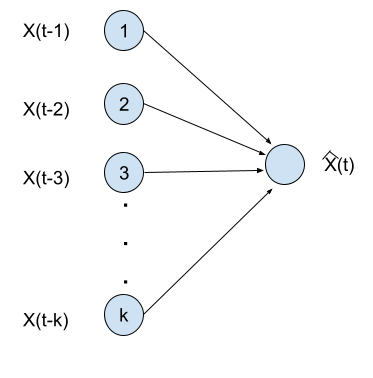

## Define the naive m layer auto-regresssive network

In [61]:
tokens = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

class AttrProxy(object):
    """Translates index lookups into attribute lookups."""
    def __init__(self, module, prefix):
        self.module = module
        self.prefix = prefix

    def __getitem__(self, i):
        return getattr(self.module, self.prefix + str(i))


class AR(nn.Module):
    def __init__(self, window, layer=1):
        super(AR, self).__init__()
        self.layer_no = layer+1
        
        for ii in range(layer+1):
            if ii == 0:
                self.add_module('h_' + str(ii), nn.Flatten())
            elif ii == 1:
                self.add_module('h_' + str(ii), nn.Linear(window*len(tokens), len(tokens)))
            else:
                self.add_module('h_' + str(ii), nn.Linear(len(tokens), len(tokens)))

        self.hidden = AttrProxy(self, 'h_')


    def forward(self, x):
        x = self.hidden[0](x)
        
        for ii in range(1,self.layer_no-1):
            h = self.hidden[ii]
            x = torch.nn.functional.relu(h(x))

        x = self.hidden[self.layer_no-1](x)
        x = torch.nn.functional.softmax(x, dim=1)
        return x


## Define dataset with one hot encoding

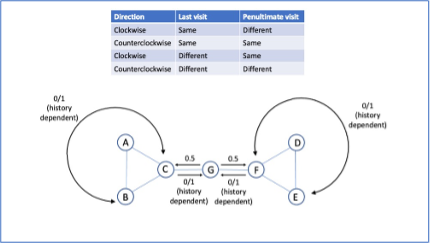

In [62]:
class Dataset_converter(Dataset):
    def __init__(self, data, window=2):
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((len(data)-window, window, len(tokens)))
        self.y = np.zeros((len(data)-window, len(tokens)))

        for ii in range(len(data)-window):
            self.X[ii] = one_hot_encoded[ii:ii+window,:]
            self.y[ii] = one_hot_encoded[ii+window,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [63]:
class Dataset_converter_rnn(Dataset):
    def __init__(self, data):
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((len(data)-1, len(tokens)))
        self.y = np.zeros((len(data)-1, len(tokens)))

        for ii in range(len(data)-1):
            self.X[ii] = one_hot_encoded[ii]
            self.y[ii] = one_hot_encoded[ii+1]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

## Load dataset

In [64]:
data = pd.read_csv("Seq_500000.txt")['seq'][0]

## Perform the experiment for linear AR models(each repeated 10 times)

In [81]:
reps = 5
layer_no = [1,2,3,4,5]
lr = 1e-1
window = 8
test_acc = np.zeros((len(layer_no), reps, len(data)), dtype=float)
index_len = []

for ii, layer_size in enumerate(layer_no):
    print('Doing layer no ', layer_size)
    
    data_set = Dataset_converter(data, window)
    index_len.append(len(data_set))
    
    for rep in tqdm(range(reps)):
        torch.manual_seed(rep)
        model = AR(window, layer=layer_size)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
        
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        criterion = torch.nn.MSELoss()

        total = 0
        correct = 0
        jj = 0
        for X, y in train_loader:
            optimizer.zero_grad()
            predicted_y = model(X)
            loss = criterion(predicted_y, y)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                total += 1

                if y.argmax() == predicted_y.argmax():
                        correct += 1

                test_acc[ii,rep,jj] = correct/total
                
                #print(f'Iter : {jj+1}, loss: {loss:.4f}')
                jj += 1
            

Doing layer no  1


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [05:05<00:00, 61.17s/it]


Doing layer no  2


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [06:43<00:00, 80.67s/it]


Doing layer no  3


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [08:20<00:00, 100.14s/it]


Doing layer no  4


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [09:55<00:00, 119.11s/it]


Doing layer no  5


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [11:28<00:00, 137.70s/it]


## Plot the result

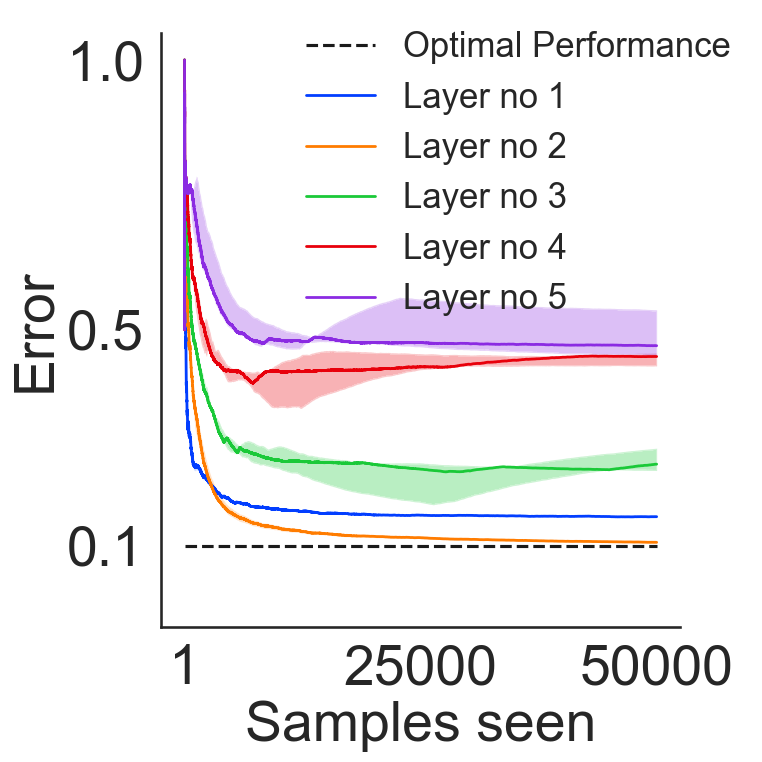

In [82]:
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40
samples_to_show = 50000

fig, ax = plt.subplots(1, 1, figsize=(8,8))

ax.hlines(0.1, 0, samples_to_show, linestyles='dashed', label='Optimal Performance', color='k')

for ii, l in enumerate(layer_no):
    ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc[ii,:,:samples_to_show],axis=0),linewidth=2, label='Layer no '+ str(l))
    ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc[ii,:,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc[ii,:,:samples_to_show], 0.75, axis=0), alpha=.3)

leg = fig.legend(fontsize=25, frameon=False)


ax.set_xticks([1, samples_to_show//2, samples_to_show])
ax.set_yticks([0.1, 0.5, 1.0])

ax.set_xlabel('Samples seen', fontsize=font)
ax.set_ylabel('Error', fontsize=font)

ax.tick_params(labelsize=40)
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

plt.tight_layout()


# Todos
1. GELU and MISH